**Import Libraries**

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,confusion_matrix
from sklearn.ensemble import RandomForestClassifier

**Load Dataset**

In [2]:
df = pd.read_csv("employee_turnover.csv")

In [3]:
df.head()
df.info()
df.isnull().sum()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1350 entries, 0 to 1349
Data columns (total 16 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Job_Satisfaction                         1350 non-null   float64
 1   Performance_Rating                       1350 non-null   float64
 2   Years_At_Company                         1350 non-null   float64
 3   Work_Life_Balance                        1350 non-null   float64
 4   Distance_From_Home                       1350 non-null   float64
 5   Monthly_Income                           1350 non-null   float64
 6   Education_Level                          1350 non-null   float64
 7   Age                                      1350 non-null   float64
 8   Num_Companies_Worked                     1350 non-null   float64
 9   Employee_Role                            1350 non-null   float64
 10  Annual_Bonus                             1350 no

Index(['Job_Satisfaction', 'Performance_Rating', 'Years_At_Company',
       'Work_Life_Balance', 'Distance_From_Home', 'Monthly_Income',
       'Education_Level', 'Age', 'Num_Companies_Worked', 'Employee_Role',
       'Annual_Bonus', 'Training_Hours', 'Department', 'Annual_Bonus_Squared',
       'Annual_Bonus_Training_Hours_Interaction', 'Employee_Turnover'],
      dtype='object')

In [4]:
x = df.drop("Employee_Turnover",axis = 1)

In [5]:
y = df["Employee_Turnover"]

**EDA**

Text(0.5, 1.0, 'Employee Turnover Distribution')

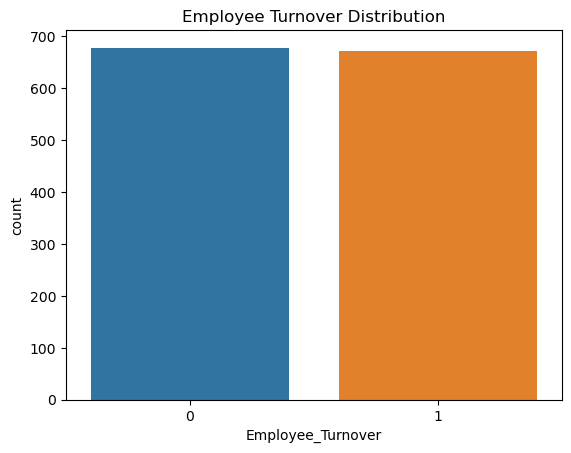

In [9]:
sns.countplot(x="Employee_Turnover", data=df)
plt.title("Employee Turnover Distribution")

Text(0.5, 1.0, 'Salary Distribution vs Turnover')

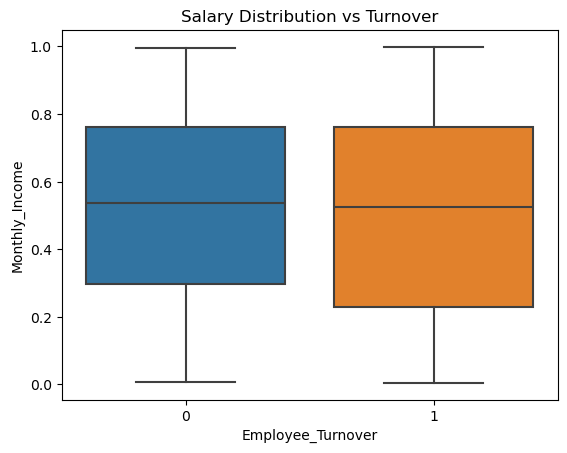

In [12]:
sns.boxplot(x="Employee_Turnover", y="Monthly_Income", data=df)
plt.title("Salary Distribution vs Turnover")

**Train Test Split**

In [13]:
#train test split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

**RandomForestClassifier**

In [21]:
#model 
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [22]:
y_pred = model.predict(x_test)

**Results**

In [25]:
Accuracy = print("accuracy_score",accuracy_score(y_test,y_pred))
Precision = print("Precision:", precision_score(y_test, y_pred))
Recall = print("Recall:", recall_score(y_test, y_pred))
confusion_matrix = print("confusion_matrix",confusion_matrix(y_test,y_pred))

accuracy_score 0.9111111111111111
Precision: 0.9105691056910569
Recall: 0.896
confusion_matrix [[134  11]
 [ 13 112]]


Text(0.5, 1.0, 'Confusion Matrix - Random Forest')

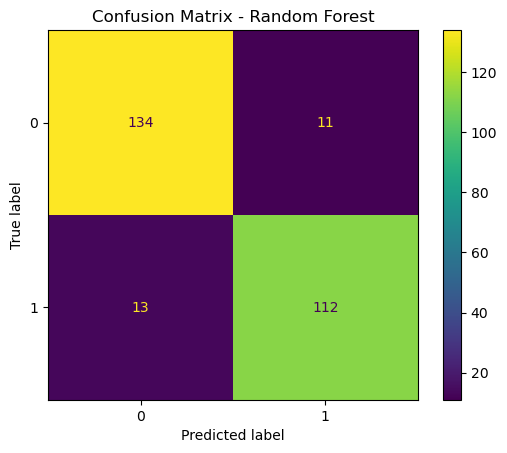

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, x_test, y_test)
plt.title("Confusion Matrix - Random Forest")

**Conclusion ->
Random Forest Classifier achieved the highest performance among all models tested, with an accuracy of 91.11%. This indicates that ensemble learning methods are more effective for this dataset compared to individual models like Logistic Regression and Decision Tree. The model captures complex patterns and interactions between features, resulting in improved prediction of employee turnover.**